In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
import copy
import seaborn as sns
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset, ConcatDataset

#import umap
#import hdbscan
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split, KFold
from sklearn.metrics import adjusted_rand_score
from tqdm import tqdm

In [2]:
def read_unequal_table(txt_file, num_columns=383, filler=''):
    """Read table from file."""
    table = []
    with open(txt_file) as file:
        for row in file:
            values = row.split()
            if len(values) > num_columns:
                raise ValueError('Number of values more than num_columns')
            elif len(values) < num_columns:
                diff = num_columns - len(values)
                padding = [filler]*diff
                values = values + padding
            else:
                pass
            table.append(values)
    return np.array(table)

In [3]:
def read_norm_spectra(txt_file):
    """Read the saved set of normalized spectra"""
    alldata = read_unequal_table(txt_file)
    srcids = alldata[:, 0].astype(str)
    normed_spectra = alldata[:, 1:-2].astype(float)
    netcounts = alldata[:, -2].astype(float)
    src_class = alldata[:, -1].astype(str)
    return srcids, normed_spectra, netcounts, src_class

In [4]:
def refine_labels(label_array):
    """Refine labels to 4 classes."""
    refined_labels = np.full(len(label_array), '', dtype='<U16')
    for i, label in enumerate(label_array):
        if label == '':
            continue
        if label == 'AGN' or label == 'CV':
            refined_labels[i] = label
        elif label == 'LM-STAR' or label == 'HM-STAR' or label == 'YSO':
            refined_labels[i] = 'STAR'
        else:
            refined_labels[i] = 'NS/BH'
    return refined_labels

In [5]:
pn_srcids, pn_normspec, pn_counts, pn_class = read_norm_spectra('../Data/Brightmos_id_normspec_counts_label.txt')

In [6]:
pn_class_refined = refine_labels(pn_class)

In [7]:
def check_spectra(normspec, refinedclass):
    """Check the normalized spectra of different classes."""
    en_bins = np.linspace(0.5, 10, len(normspec[0]))
    classes_unique = np.unique(refinedclass)
    plt.figure(figsize=(20, 12))
    plt.xlabel('Energy [keV]')
    plt.ylabel('Normalized counts [/bin]')
    plt.xscale('log')
    plt.xlim(0.5, 10.0)
    for classes in classes_unique:
        if classes != '':
            plt.plot(en_bins,
                     np.mean(normspec[refinedclass == classes], axis=0), label=classes)
    plt.legend()
    plt.show()

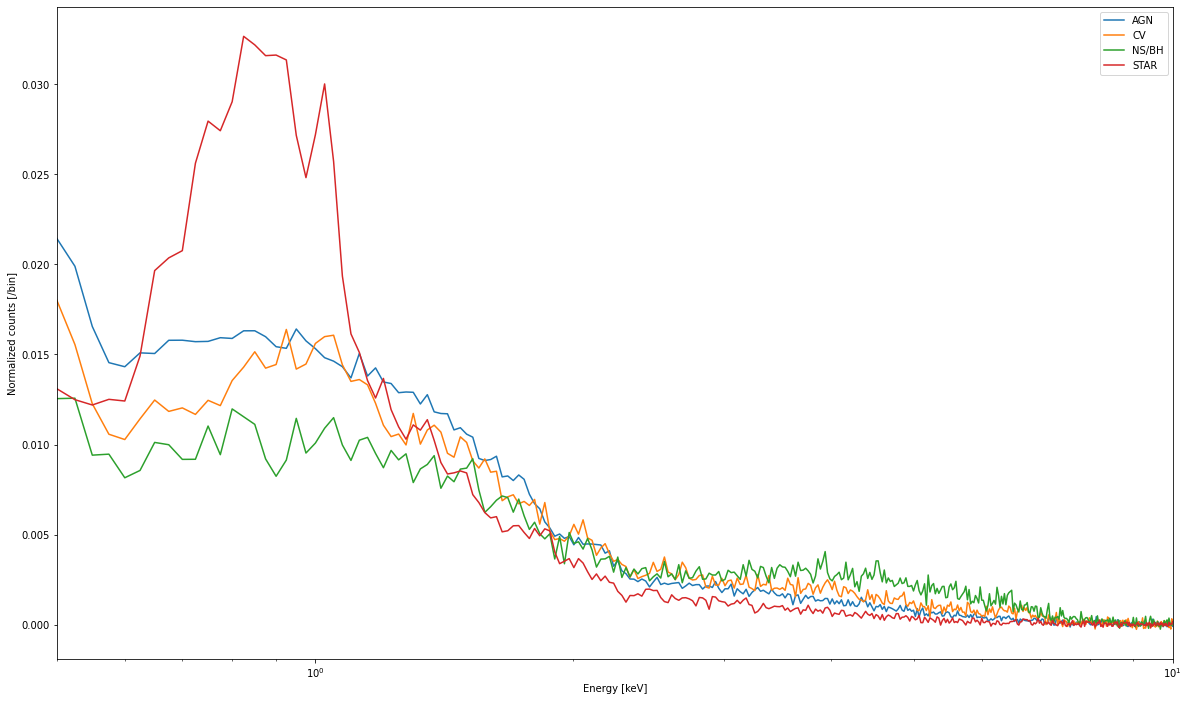

In [8]:
check_spectra(pn_normspec, pn_class_refined)

In [9]:
labelled_args = np.where(pn_class_refined != '')[0]
unlabelled_args = np.where(pn_class_refined == '')[0]
pn_normspec_labelled = pn_normspec[labelled_args]
pn_spec_labels = np.zeros(len(labelled_args), dtype=int)
pn_counts_labelled = pn_counts[labelled_args]
pn_spec_labels[pn_class_refined[labelled_args] == 'STAR'] = 1
pn_spec_labels[pn_class_refined[labelled_args] == 'NS/BH'] = 2
pn_spec_labels[pn_class_refined[labelled_args] == 'CV'] = 3

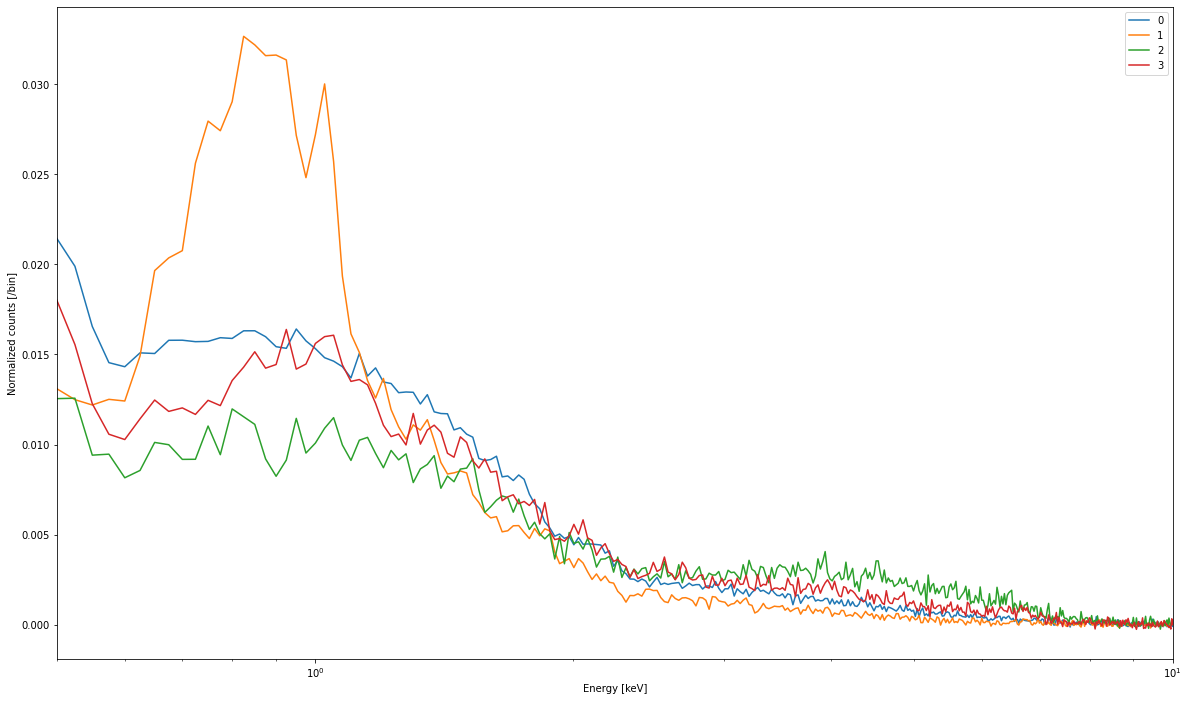

In [10]:
check_spectra(pn_normspec_labelled, pn_spec_labels)

In [13]:
pn_labelled_trainids = np.loadtxt('Train_MOS_indices_forall_labelled.txt')
pn_labelled_testids = np.loadtxt('Test_MOS_indices_forall_labelled.txt')

In [14]:
# =========================================================
# Simple Semi-supervised Autoencoder + Classifier
# =========================================================
class SemiSupervisedAE(nn.Module):
    def __init__(self, num_classes=4, latent_dim=32, drop=0.0, l_noise=0.05):
        super().__init__()

        # ---------- Encoder ----------
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=7, padding=3),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.MaxPool1d(2),

            nn.Conv1d(8, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.MaxPool1d(2),
        )

        # compute encoded feature size
        self._enc_out_dim = 16 * (380 // 4)  # assuming input length 380
        self.fc_enc = nn.Linear(self._enc_out_dim, latent_dim)
        self.latent_noise_std = l_noise

        # ---------- Decoder ----------
        self.fc_dec = nn.Linear(latent_dim, self._enc_out_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.ConvTranspose1d(8, 1, kernel_size=7, padding=3),
            nn.Softplus()  # ensures positive reconstructed counts
        )

        # ---------- Classifier ----------
        self.classifier = nn.Sequential(
            # nn.Linear(latent_dim, 64),
            # nn.ReLU(),
            nn.Linear(latent_dim, num_classes)
        )

    def forward(self, x):
        # x: (B, 1, 380)
        z = self.encoder(x)
        z = z.view(x.size(0), -1)
        z = self.fc_enc(z)
        if self.training and self.latent_noise_std > 0:
            dim_std = z.std(dim=0, unbiased=False,
                            keepdim=True).clamp(min=1e-3)
            z_decode = z + torch.randn_like(z)*self.latent_noise_std*dim_std
            z_class = z + torch.randn_like(z)*(self.latent_noise_std*4*dim_std)
            # print(torch.randn_like(z)*self.latent_noise_std*5*dim_std)
        else:
            z_decode = z
            z_class = z

        # Decode
        dec = self.fc_dec(z_decode)
        dec = dec.view(x.size(0), 16, 380 // 4)
        x_hat = self.decoder(dec)

        # Upsample back to 380 bins
        x_hat = nn.functional.interpolate(x_hat, size=380, mode="linear")

        # Classify
        # z = self.dropout_latent(z)
        logits = self.classifier(z_class)
        return x_hat, logits, z


def l1_penalty(model):
    l1_norm = sum(p.abs().sum() for p in model.parameters())
    return l1_norm


def poisson_recon_loss(x, x_hat, total_counts=1.0, eps=1e-6):
    """
    x: original *normalized* input spectrum  (values sum to 1)
    x_hat: reconstructed normalized spectrum (values sum to ~1)
    total_counts: original total counts before normalization (scalar or tensor)
    """
    # ensure torch tensor
    if not torch.is_tensor(total_counts):
        total_counts = torch.tensor(total_counts, dtype=x.dtype,
                                    device=x.device)
    # reshape for broadcasting (B, 1, 1)
    if total_counts.ndim == 1:
        total_counts = total_counts.view(-1, 1, 1)

    # rescale both spectra back to original count scale
    # total_counts = total_counts.view(-1, 1, 1)
    x_rescaled = torch.clamp(x * total_counts, min=eps)
    x_hat_rescaled = torch.clamp(x_hat * total_counts, min=eps)

    # standard Poisson negative log-likelihood loss (ignoring constants)
    loss = ((x_hat_rescaled - x_rescaled +
             x_rescaled * torch.log(x_rescaled + eps) -
             x_rescaled * torch.log(x_hat_rescaled + eps)).sum(dim=2) /
            total_counts.view(-1, 1)).mean(dim=0)
    # print(loss.shape)
    return loss

def smoothness_loss(x_hat):
    # Penalize large gradients between neighboring bins
    return torch.mean(torch.abs(x_hat[:, :, 1:] - x_hat[:, :, :-1]).sum(dim=2))


def train_semisupervised(model, optimizer, labeled_loader, unlabeled_loader,
                         lambda_cls=2.0, device=None, epochs=20, l1_lam=0.0,
                         l_smooth=10, l_latent=1.0e-3,
                         scheduler=None, val_loader=None,
                         temp_filename='best_model', weights=None):
    """Train a supervised Autoencoder with classification loss."""
    if device is None:
        device='cuda' if torch.cuda.is_available() else 'cpu'
   
    model.to(device)
    if weights is None:
        ce_loss = nn.CrossEntropyLoss()
    else:
        ce_loss = nn.CrossEntropyLoss(weight=torch.tensor(weights).to(device))
    print(lambda_cls, l1_lam, l_smooth)
    
    #best_val_loss = float("inf")
    #best_epoch = -1
    #epochs_no_improve = 0
    #no_improve_patience = 12

    for epoch in range(epochs):
        print(f'Epoch {epoch}')
        model.train()
        total_loss = total_cls = total_recon = total_smooth = tot_latent = 0.0
        total_rloss_l = total_rloss_u = 0.0

        # main iterator: unlabeled batches
        labeled_iter = iter(labeled_loader)

        #for xbu in tqdm(unlabeled_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        for xbu in unlabeled_loader:
            xbu = xbu[0].to(device)

            # fetch or resample labeled batch
            try:
                xb, yb = next(labeled_iter)
            except StopIteration:
                labeled_list = list(labeled_loader)
                xb, yb = random.choice(labeled_list)
            xb, yb = xb.to(device), yb.to(device)
            
            # Seperate counts and normalized spectra
            xbu_counts = xbu[:, :, -1].view(-1, 1, 1)
            xbu = xbu[:, :, :-1]
            xb_counts = xb[:, :, -1].view(-1, 1, 1)
            xb = xb[:, :, :-1]

            # forward passes
            x_hat_l, logits, z_l = model(xb)
            x_hat_u, _, z_u = model(xbu)

            # losses
            recon_loss_l = poisson_recon_loss(xb, x_hat_l, xb_counts)
            recon_loss_u = poisson_recon_loss(xbu, x_hat_u, xbu_counts)
            loss_recon = ((recon_loss_l*len(xb) + recon_loss_u*len(xbu)) /
                          (len(xb) + len(xbu)))
            loss_cls = ce_loss(logits, yb)
            loss = loss_recon + lambda_cls * loss_cls

            if l_latent > 0.0:
                loss_latent = ((torch.mean(z_l.pow(2))*len(xb) +
                                torch.mean(z_u.pow(2))*len(xbu)) /
                               (len(xb) + len(xbu)))
                loss += l_latent*loss_latent
            
            if l1_lam > 0.0:
                loss_l1 = l1_penalty(model)
                loss += l1_lam*loss_l1
            
            if l_smooth > 0.0:
                loss_smooth = (
                    smoothness_loss(x_hat_l)*len(xb) +
                    smoothness_loss(x_hat_u)*len(xbu)) / (len(xb) + len(xbu))
                loss += l_smooth*loss_smooth

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_cls += loss_cls.item()
            total_smooth += loss_smooth.item()
            total_recon += loss_recon.item()
            total_rloss_l += recon_loss_l.item()
            total_rloss_u += recon_loss_u.item()
            tot_latent += loss_latent.item()

        print(f"Epoch {epoch+1}:total={total_loss/len(unlabeled_loader):.4f}, "
              f"cls={total_cls/len(unlabeled_loader):.4f}, "
              f"recon={total_recon/len(unlabeled_loader):.4f} "
              f"({total_rloss_l/len(unlabeled_loader):.4f}, "
              f"{total_rloss_u/len(unlabeled_loader):.4f}), ",
              f"smooth={total_smooth/len(unlabeled_loader):.4f}, "
              f"latent={tot_latent/len(unlabeled_loader):.4f}")
        if val_loader is not None:
            # Get validation loss
            model.eval()
            val_loss, val_items, corr = 0.0, 0, 0
            val_loss_r, val_loss_c, val_loss_s, val_loss_l = 0.0, 0.0, 0.0, 0.0
            val_nscv_items, val_nscv_corr = 0, 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    xb_counts = xb[:, :, -1].view(-1, 1, 1)
                    xb = xb[:, :, :-1]
                    x_hat, logits_val, z_val = model(xb)
                    val_loss_rb = poisson_recon_loss(
                        xb, x_hat, xb_counts).item()
                    val_loss_cb = ce_loss(logits_val, yb).item()
                    val_loss_sb = smoothness_loss(x_hat).item()
                    val_loss_lb = torch.mean(z_val.pow(2))
                    val_loss_b = (val_loss_rb + lambda_cls*val_loss_cb +
                                  l_smooth*val_loss_sb + l_latent*val_loss_lb +
                                  l1_lam*l1_penalty(model).item())
                    preds = torch.argmax(logits_val, dim=1)
                    val_loss += val_loss_b
                    val_loss_r += val_loss_rb
                    val_loss_c += val_loss_cb
                    val_loss_s += val_loss_sb
                    val_loss_l += val_loss_lb
                    corr += (preds == yb).sum().item()
                    val_items += xb.size(0)
                    val_nscv_items += torch.logical_or(yb==2, yb==3).sum()
                    val_nscv_corr += torch.logical_or(
                        torch.logical_and(preds==2, yb==2),
                        torch.logical_and(preds==3, yb==3)).sum()
            val_loss = val_loss/len(val_loader)
            val_loss_r = val_loss_r/len(val_loader)
            val_loss_c = val_loss_c/len(val_loader)
            val_loss_s = val_loss_s/len(val_loader)
            val_loss_l = val_loss_l/len(val_loader)
            val_acc = corr/max(val_items, 1)
            val_acc_nscv = val_nscv_corr/max(val_nscv_items, 1)
            print(f"Validation loss: {val_loss:.4f} | Val acc: {val_acc:.4f} |"
                  f"Val acc (NS/BH/CV): {val_acc_nscv:.4f} |"
                  f"val_class:{val_loss_c:.4f} val_recon:{val_loss_r:.4f} "
                  f"val_smooth: {val_loss_s:.4f} val_latent:{val_loss_l:.4f}")
            if scheduler is not None:
                old_lr = optimizer.param_groups[0]['lr']
                scheduler.step(val_loss)
                new_lr = optimizer.param_groups[0]['lr']
                if new_lr < old_lr:
                    print(f'Learning rate changed to {new_lr:.6f}')
            
            # if val_loss < best_val_loss:
            #    best_val_loss = val_loss
            #    epochs_no_improve = 0
            #    torch.save(model.state_dict(), temp_filename)
            # else:
            #    epochs_no_improve += 1

            # if epochs_no_improve >= no_improve_patience:
            #    print(f"Early stopping at epoch {epoch}")
            #    model.load_state_dict(torch.load(temp_filename))
            #    break

    return model


def semisupervised_kfold_test(models_class, labelled_data, labels,
                              unlabelled_data, num_classes=4, lambda_cls=2.0,
                              k_folds=10, lr=1e-3, epochs=20,
                              batch_size=32, ul_batch_size=512,
                              test_size=0.2, device=None,
                              l1_lambda=0.0, l2_lambda=0.0, op_alg='Adam',
                              train_ids=None, test_ids=None, weights=None):
    """
    k-fold CV on labeled data with all unlabeled data in training.
    Returns all fold models, validation & test accuracies, and best model.
    """
    if device is None:
        device='cuda' if torch.cuda.is_available() else 'cpu'

    # --- Hold-out test split ---
    if train_ids is None and test_ids is None:
        train_ids, test_ids = train_test_split(np.arange(len(labels)),
                                               test_size=test_size,
                                               stratify=labels,
                                               random_state=32)

    X_trainval = labelled_data[train_ids]
    X_test = labelled_data[test_ids]
    y_trainval = labels[train_ids]
    y_test = labels[test_ids]
    test_ds = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_test, dtype=torch.long))
    train_spec = torch.tensor(X_trainval, dtype=torch.float32).unsqueeze(1)
    spec_label = torch.tensor(y_trainval, dtype=torch.long)
    train_data = TensorDataset(train_spec, spec_label)

    test_loader = DataLoader(test_ds, batch_size=batch_size)

    # Unlabeled loader
    unl_ds = TensorDataset(
        torch.tensor(unlabelled_data, dtype=torch.float32).unsqueeze(1))
    unl_loader = DataLoader(unl_ds, batch_size=ul_batch_size, shuffle=True)

    # --- K-fold CV ---
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_spec,
                                                          spec_label), 1):
        print(f"\n=== Fold {fold}/{k_folds} ===")

        #X_train, y_train = X_trainval[train_idx], y_trainval[train_idx]
        #X_val, y_val = X_trainval[val_idx], y_trainval[val_idx]
        train_ds = torch.utils.data.Subset(train_data, train_idx)
        val_ds = torch.utils.data.Subset(train_data, val_idx) 

        #train_ds = TensorDataset(
        #    torch.tensor(X_train, dtype=torch.float32).unsqueeze(1),
        #    torch.tensor(y_train, dtype=torch.long))
        #val_ds = TensorDataset(
        #    torch.tensor(X_val, dtype=torch.float32).unsqueeze(1),
        #    torch.tensor(y_val, dtype=torch.long))

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)

        # Model + optimizer
        model = models_class(num_classes=num_classes).to(device)
        if op_alg == 'Adam':
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        else:
            optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                                        weight_decay=l2_lambda, nesterov=True)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.25, patience=5, min_lr=1e-6)


        # Train
        model = train_semisupervised(
            model, optimizer, train_loader, unl_loader, lambda_cls=lambda_cls,
            device=device, epochs=epochs, l1_lam=l1_lambda,
            scheduler=scheduler, val_loader=val_loader,
            temp_filename=f"best_model_temp_{fold}.pt", weights=weights)
        train_acc, train_acc_nscv = evaluate(model, train_loader, device)

        # --- Validation accuracy ---
        val_acc, val_acc_nscv = evaluate(model, val_loader, device)

        # --- Test accuracy ---
        test_acc, test_acc_nscv = evaluate(model, test_loader, device)
        print(f"Train accuracy: {train_acc:.5f} ({train_acc_nscv:.5f})| "
              f"Val accuracy: {val_acc:.5f} ({val_acc_nscv:.5f}) | "
              f"Test accuracy: {test_acc:.5f} ({test_acc_nscv:.5f})")

        results.append({'model': model,
                        'val_acc': val_acc,
                        'test_acc': test_acc,
                        'val_acc_nscv': val_acc_nscv,
                        'test_acc_nscv': test_acc_nscv})

    return results, train_ds, test_ds


def evaluate(model, data_loader, device):
    """Evaluate model and return accuracy"""
    correct, total = 0, 0
    corr_nscv, total_nscv = 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            _, logits, _ = model(xb[:, :, :-1])  # Remove total counts column
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
            total_nscv += torch.logical_or(yb==2, yb==3).sum()
            corr_nscv += torch.logical_or(
                torch.logical_and(preds==2, yb==2),
                torch.logical_and(preds==3, yb==3)).sum()
        acc_val = correct / total
        acc_nscv_val = corr_nscv/total_nscv
    return acc_val, acc_nscv_val
            

In [15]:
class_counts = np.array([720, 621, 81, 81])
class_weights = 1/class_counts
class_weights = class_weights/np.sum(class_weights)
print(class_weights**0.5)

[0.2239587  0.24115062 0.66771584 0.66771584]


In [16]:
all_results, train_data, test_data = semisupervised_kfold_test(
    SemiSupervisedAE,
    np.column_stack([pn_normspec_labelled, pn_counts_labelled]),
    pn_spec_labels,
    np.column_stack([pn_normspec[unlabelled_args], pn_counts[unlabelled_args]]),
    epochs=20, lambda_cls=10, l2_lambda=1.0e-3, l1_lambda=1.0e-4, lr=1.0e-3,
    train_ids=pn_labelled_trainids.astype(int),
    test_ids=pn_labelled_testids.astype(int),
    weights=(class_weights**0.5).tolist())


=== Fold 1/10 ===
10 0.0001 10
Epoch 0
Epoch 1:total=43.6062, cls=1.2196, recon=21.2180 (21.1377, 21.2226),  smooth=0.9632, latent=33.3446
Validation loss: 13.5571 | Val acc: 0.7107 |Val acc (NS/BH/CV): 0.3846 |val_class:0.9712 val_recon:2.6569 val_smooth: 0.0629 val_latent:31.1670
Epoch 1
Epoch 2:total=11.3469, cls=0.8041, recon=2.1080 (1.5796, 2.1406),  smooth=0.0643, latent=27.8513
Validation loss: 11.6149 | Val acc: 0.6033 |Val acc (NS/BH/CV): 0.3846 |val_class:0.9096 val_recon:1.4985 val_smooth: 0.0466 val_latent:27.8130
Epoch 2
Epoch 3:total=9.9012, cls=0.7507, recon=1.3200 (1.0788, 1.3351),  smooth=0.0524, latent=23.0495
Validation loss: 10.4033 | Val acc: 0.7686 |Val acc (NS/BH/CV): 0.3846 |val_class:0.8116 val_recon:1.4900 val_smooth: 0.0242 val_latent:28.4264
Epoch 3
Epoch 4:total=8.5015, cls=0.6381, recon=1.1578 (0.9895, 1.1682),  smooth=0.0413, latent=22.0020
Validation loss: 10.0296 | Val acc: 0.8843 |Val acc (NS/BH/CV): 0.2308 |val_class:0.8023 val_recon:0.9026 val_smoot

Epoch 13:total=5.8305, cls=0.4113, recon=0.9395 (1.0433, 0.9330),  smooth=0.0230, latent=16.1316
Validation loss: 21.5808 | Val acc: 0.5868 |Val acc (NS/BH/CV): 0.1538 |val_class:1.9109 val_recon:1.8559 val_smooth: 0.0056 val_latent:27.2291
Epoch 13
Epoch 14:total=5.2944, cls=0.3586, recon=0.9309 (0.9553, 0.9293),  smooth=0.0228, latent=15.8441
Validation loss: 10.8150 | Val acc: 0.8347 |Val acc (NS/BH/CV): 0.2308 |val_class:0.8987 val_recon:0.9299 val_smooth: 0.0350 val_latent:14.1640
Epoch 14
Epoch 15:total=4.9794, cls=0.3282, recon=0.9242 (0.9134, 0.9249),  smooth=0.0223, latent=15.6311
Validation loss: 15.8794 | Val acc: 0.7686 |Val acc (NS/BH/CV): 0.0769 |val_class:1.3958 val_recon:0.9724 val_smooth: 0.0398 val_latent:14.9572
Epoch 15
Epoch 16:total=4.8957, cls=0.3198, recon=0.9255 (0.9436, 0.9243),  smooth=0.0221, latent=15.5001
Validation loss: 16.3680 | Val acc: 0.7686 |Val acc (NS/BH/CV): 0.3846 |val_class:1.4174 val_recon:1.5536 val_smooth: 0.0080 val_latent:23.7758
Epoch 16


Epoch 5:total=8.5693, cls=0.6410, recon=1.1647 (1.0044, 1.1747),  smooth=0.0436, latent=28.6274
Validation loss: 22.1466 | Val acc: 0.8333 |Val acc (NS/BH/CV): 0.3333 |val_class:0.7285 val_recon:8.2489 val_smooth: 0.6072 val_latent:10.0017
Epoch 5
Epoch 6:total=7.7212, cls=0.5600, recon=1.1339 (1.0226, 1.1408),  smooth=0.0428, latent=28.3623
Validation loss: 24.4977 | Val acc: 0.8583 |Val acc (NS/BH/CV): 0.2500 |val_class:0.6634 val_recon:10.4588 val_smooth: 0.6863 val_latent:9.2647
Epoch 6
Epoch 7:total=7.1203, cls=0.5045, recon=1.0962 (0.9959, 1.1024),  smooth=0.0418, latent=27.8653
Validation loss: 14.3280 | Val acc: 0.8250 |Val acc (NS/BH/CV): 0.3333 |val_class:0.6599 val_recon:4.1703 val_smooth: 0.3012 val_latent:12.9096
Epoch 7
Epoch 8:total=6.2679, cls=0.4224, recon=1.0881 (0.9922, 1.0941),  smooth=0.0394, latent=27.3990
Validation loss: 11.7858 | Val acc: 0.8417 |Val acc (NS/BH/CV): 0.0000 |val_class:0.8195 val_recon:1.7789 val_smooth: 0.1258 val_latent:18.1181
Epoch 8
Epoch 9:

Epoch 18:total=3.3553, cls=0.1683, recon=0.9097 (0.9131, 0.9095),  smooth=0.0202, latent=18.6675
Validation loss: 10.5711 | Val acc: 0.8083 |Val acc (NS/BH/CV): 0.0833 |val_class:0.8912 val_recon:0.8979 val_smooth: 0.0200 val_latent:18.6179
Epoch 18
Epoch 19:total=3.3343, cls=0.1670, recon=0.9031 (0.8652, 0.9055),  smooth=0.0199, latent=18.7371
Validation loss: 10.4148 | Val acc: 0.8000 |Val acc (NS/BH/CV): 0.4167 |val_class:0.7450 val_recon:1.8287 val_smooth: 0.0580 val_latent:11.5455
Epoch 19
Epoch 20:total=3.1507, cls=0.1491, recon=0.9003 (0.8664, 0.9024),  smooth=0.0196, latent=18.4488
Validation loss: 9.7085 | Val acc: 0.8750 |Val acc (NS/BH/CV): 0.2500 |val_class:0.7847 val_recon:0.9796 val_smooth: 0.0322 val_latent:15.2511
Learning rate changed to 0.000250
Train accuracy: 0.96214 (0.66379)| Val accuracy: 0.87500 (0.25000) | Test accuracy: 0.80000 (0.14706)

=== Fold 6/10 ===
10 0.0001 10
Epoch 0
Epoch 1:total=273.9231, cls=1.4179, recon=215.1512 (216.9813, 215.0375),  smooth=4.4

Epoch 10:total=4.7007, cls=0.2890, recon=0.9549 (0.8570, 0.9609),  smooth=0.0297, latent=22.3263
Validation loss: 9.6981 | Val acc: 0.8250 |Val acc (NS/BH/CV): 0.4615 |val_class:0.7298 val_recon:1.2507 val_smooth: 0.0594 val_latent:17.7139
Epoch 10
Epoch 11:total=4.0972, cls=0.2299, recon=0.9509 (0.8577, 0.9568),  smooth=0.0287, latent=22.1802
Validation loss: 20.4831 | Val acc: 0.5167 |Val acc (NS/BH/CV): 0.1538 |val_class:1.8302 val_recon:1.4376 val_smooth: 0.0173 val_latent:31.5480
Epoch 11
Epoch 12:total=3.5133, cls=0.1741, recon=0.9360 (0.8463, 0.9416),  smooth=0.0275, latent=21.7671
Validation loss: 28.3687 | Val acc: 0.4667 |Val acc (NS/BH/CV): 0.1538 |val_class:2.6140 val_recon:1.4761 val_smooth: 0.0180 val_latent:31.9878
Epoch 12
Epoch 13:total=3.2489, cls=0.1494, recon=0.9275 (0.8371, 0.9332),  smooth=0.0265, latent=21.5189
Validation loss: 10.3480 | Val acc: 0.8000 |Val acc (NS/BH/CV): 0.4615 |val_class:0.7634 val_recon:1.4659 val_smooth: 0.0691 val_latent:15.2060
Learning r

Epoch 2:total=12.1010, cls=0.8933, recon=2.1089 (1.5299, 2.1451),  smooth=0.0511, latent=21.5364
Validation loss: 13.6109 | Val acc: 0.7750 |Val acc (NS/BH/CV): 0.3077 |val_class:0.9991 val_recon:1.4343 val_smooth: 0.1647 val_latent:12.4324
Epoch 2
Epoch 3:total=10.1976, cls=0.7981, recon=1.2188 (1.0392, 1.2300),  smooth=0.0454, latent=18.2389
Validation loss: 16.6558 | Val acc: 0.7833 |Val acc (NS/BH/CV): 0.1538 |val_class:1.0100 val_recon:3.2456 val_smooth: 0.2775 val_latent:8.6098
Epoch 3
Epoch 4:total=8.8211, cls=0.6840, recon=1.0682 (0.9540, 1.0756),  smooth=0.0369, latent=17.5582
Validation loss: 14.3571 | Val acc: 0.8250 |Val acc (NS/BH/CV): 0.2308 |val_class:1.0276 val_recon:1.8796 val_smooth: 0.1664 val_latent:10.8475
Epoch 4
Epoch 5:total=8.1834, cls=0.6258, recon=1.0359 (0.9834, 1.0392),  smooth=0.0345, latent=17.5352
Validation loss: 15.7169 | Val acc: 0.7833 |Val acc (NS/BH/CV): 0.1538 |val_class:1.0179 val_recon:2.8677 val_smooth: 0.2134 val_latent:8.9546
Epoch 5
Epoch 6:

Epoch 15:total=4.6781, cls=0.2864, recon=0.9703 (0.8994, 0.9747),  smooth=0.0287, latent=23.2992
Validation loss: 8.8976 | Val acc: 0.8083 |Val acc (NS/BH/CV): 0.4615 |val_class:0.7080 val_recon:0.9486 val_smooth: 0.0312 val_latent:23.3073
Epoch 15
Epoch 16:total=4.4265, cls=0.2618, recon=0.9650 (0.8940, 0.9695),  smooth=0.0286, latent=23.2817
Validation loss: 9.2242 | Val acc: 0.8250 |Val acc (NS/BH/CV): 0.3846 |val_class:0.7395 val_recon:0.9506 val_smooth: 0.0322 val_latent:22.8918
Epoch 16
Epoch 17:total=4.2792, cls=0.2472, recon=0.9678 (0.9284, 0.9703),  smooth=0.0282, latent=23.3642
Validation loss: 10.3030 | Val acc: 0.8250 |Val acc (NS/BH/CV): 0.3077 |val_class:0.8286 val_recon:1.0036 val_smooth: 0.0459 val_latent:20.0645
Epoch 17
Epoch 18:total=4.1119, cls=0.2311, recon=0.9600 (0.8896, 0.9643),  smooth=0.0283, latent=23.3927
Validation loss: 9.7076 | Val acc: 0.8167 |Val acc (NS/BH/CV): 0.3846 |val_class:0.7774 val_recon:0.9730 val_smooth: 0.0405 val_latent:21.0698
Epoch 18
Epo

In [23]:
all_results2, train_data, test_data = semisupervised_kfold_test(
    SemiSupervisedAE,
    np.column_stack([pn_normspec_labelled, pn_counts_labelled]),
    pn_spec_labels,
    np.column_stack([pn_normspec[unlabelled_args], pn_counts[unlabelled_args]]),
    epochs=20, lambda_cls=10, l2_lambda=1.0e-3, l1_lambda=1.0e-4, lr=1.0e-3,
    train_ids=pn_labelled_trainids.astype(int),
    test_ids=pn_labelled_testids.astype(int),
    weights=(class_weights).tolist(), k_folds=5)


=== Fold 1/10 ===
10 0.0001 10
Epoch 0
Epoch 1:total=36.4426, cls=1.2503, recon=14.9624 (15.1874, 14.9525),  smooth=0.8431, latent=22.3895
Validation loss: 13.1305 | Val acc: 0.7397 |Val acc (NS/BH/CV): 0.2353 |val_class:1.0435 val_recon:1.1221 val_smooth: 0.1034 val_latent:14.8182
Epoch 1
Epoch 2:total=11.4713, cls=0.9194, recon=1.2596 (1.1347, 1.2670),  smooth=0.0474, latent=18.7579
Validation loss: 12.2373 | Val acc: 0.7489 |Val acc (NS/BH/CV): 0.4118 |val_class:0.9936 val_recon:1.0795 val_smooth: 0.0681 val_latent:15.1028
Epoch 2
Epoch 3:total=9.6410, cls=0.7480, recon=1.2130 (1.0990, 1.2206),  smooth=0.0403, latent=17.6562
Validation loss: 12.5691 | Val acc: 0.8311 |Val acc (NS/BH/CV): 0.1176 |val_class:1.0211 val_recon:1.1982 val_smooth: 0.0617 val_latent:14.3932
Epoch 3
Epoch 4:total=7.8696, cls=0.5805, recon=1.1644 (1.0847, 1.1710),  smooth=0.0353, latent=17.1681
Validation loss: 12.2987 | Val acc: 0.8265 |Val acc (NS/BH/CV): 0.3529 |val_class:1.0348 val_recon:0.9844 val_smoot

Epoch 14:total=3.5777, cls=0.1705, recon=1.0670 (0.9767, 1.0732),  smooth=0.0239, latent=16.1600
Validation loss: 15.6779 | Val acc: 0.8493 |Val acc (NS/BH/CV): 0.5882 |val_class:1.3835 val_recon:1.1222 val_smooth: 0.0151 val_latent:19.0528
Epoch 14
Epoch 15:total=3.4386, cls=0.1574, recon=1.0637 (0.9618, 1.0694),  smooth=0.0234, latent=16.2807
Validation loss: 16.6028 | Val acc: 0.8311 |Val acc (NS/BH/CV): 0.4706 |val_class:1.4575 val_recon:1.0754 val_smooth: 0.0387 val_latent:13.7641
Epoch 15
Epoch 16:total=3.2601, cls=0.1402, recon=1.0582 (0.9518, 1.0649),  smooth=0.0232, latent=16.1577
Validation loss: 15.6695 | Val acc: 0.8402 |Val acc (NS/BH/CV): 0.5294 |val_class:1.3947 val_recon:0.9137 val_smooth: 0.0241 val_latent:16.1766
Epoch 16
Epoch 17:total=3.2403, cls=0.1385, recon=1.0567 (0.9403, 1.0658),  smooth=0.0230, latent=16.3316
Validation loss: 17.8024 | Val acc: 0.8311 |Val acc (NS/BH/CV): 0.4118 |val_class:1.5889 val_recon:1.0039 val_smooth: 0.0343 val_latent:14.2140
Epoch 17


Epoch 10:total=4.2449, cls=0.2341, recon=1.1004 (1.0246, 1.1072),  smooth=0.0237, latent=17.9663
Validation loss: 16.9678 | Val acc: 0.8257 |Val acc (NS/BH/CV): 0.4375 |val_class:1.5054 val_recon:1.0339 val_smooth: 0.0314 val_latent:16.9784
Epoch 10
Epoch 11:total=4.0363, cls=0.2137, recon=1.0962 (1.0407, 1.0989),  smooth=0.0237, latent=17.9463
Validation loss: 17.1204 | Val acc: 0.8578 |Val acc (NS/BH/CV): 0.5000 |val_class:1.5243 val_recon:1.0245 val_smooth: 0.0286 val_latent:17.2352
Epoch 11
Epoch 12:total=3.9793, cls=0.2090, recon=1.0893 (1.0140, 1.0937),  smooth=0.0233, latent=18.0299
Validation loss: 16.5753 | Val acc: 0.8578 |Val acc (NS/BH/CV): 0.5000 |val_class:1.4747 val_recon:1.0143 val_smooth: 0.0246 val_latent:18.3582
Epoch 12
Epoch 13:total=3.8644, cls=0.1979, recon=1.0854 (1.0182, 1.0898),  smooth=0.0233, latent=18.0880
Validation loss: 17.2090 | Val acc: 0.8486 |Val acc (NS/BH/CV): 0.4375 |val_class:1.5297 val_recon:1.0359 val_smooth: 0.0309 val_latent:16.7665
Epoch 13


Epoch 9:total=4.4657, cls=0.2577, recon=1.0682 (1.0165, 1.0743),  smooth=0.0252, latent=16.6626
Validation loss: 13.1541 | Val acc: 0.8532 |Val acc (NS/BH/CV): 0.3750 |val_class:1.1365 val_recon:0.9737 val_smooth: 0.0247 val_latent:16.2003
Epoch 9
Epoch 10:total=4.0736, cls=0.2204, recon=1.0593 (0.9999, 1.0631),  smooth=0.0240, latent=16.4846
Validation loss: 12.3995 | Val acc: 0.7615 |Val acc (NS/BH/CV): 0.3125 |val_class:1.0434 val_recon:1.0419 val_smooth: 0.0355 val_latent:13.9785
Learning rate changed to 0.000250
Epoch 10
Epoch 11:total=3.4700, cls=0.1621, recon=1.0484 (0.9937, 1.0523),  smooth=0.0231, latent=16.1409
Validation loss: 12.4143 | Val acc: 0.8394 |Val acc (NS/BH/CV): 0.4375 |val_class:1.0610 val_recon:0.9543 val_smooth: 0.0280 val_latent:15.1305
Epoch 11
Epoch 12:total=3.2140, cls=0.1370, recon=1.0468 (0.9895, 1.0499),  smooth=0.0226, latent=16.2725
Validation loss: 13.4058 | Val acc: 0.8440 |Val acc (NS/BH/CV): 0.5000 |val_class:1.1629 val_recon:0.9533 val_smooth: 0.0

Epoch 5:total=8.6991, cls=0.6575, recon=1.2107 (1.1192, 1.2153),  smooth=0.0362, latent=22.2800
Validation loss: 11.4392 | Val acc: 0.8073 |Val acc (NS/BH/CV): 0.4706 |val_class:0.9549 val_recon:1.0141 val_smooth: 0.0324 val_latent:21.9961
Epoch 5
Epoch 6:total=7.4426, cls=0.5367, recon=1.1969 (1.1333, 1.2024),  smooth=0.0326, latent=21.6505
Validation loss: 13.3443 | Val acc: 0.8486 |Val acc (NS/BH/CV): 0.2353 |val_class:1.1352 val_recon:1.0216 val_smooth: 0.0419 val_latent:19.8219
Epoch 6
Epoch 7:total=6.9271, cls=0.4883, recon=1.1694 (1.0970, 1.1749),  smooth=0.0320, latent=20.7799
Validation loss: 16.6894 | Val acc: 0.8532 |Val acc (NS/BH/CV): 0.1765 |val_class:1.4735 val_recon:1.1923 val_smooth: 0.0203 val_latent:23.8146
Epoch 7
Epoch 8:total=6.5517, cls=0.4524, recon=1.1700 (1.1028, 1.1765),  smooth=0.0303, latent=19.3976
Validation loss: 12.5190 | Val acc: 0.8165 |Val acc (NS/BH/CV): 0.4118 |val_class:1.0388 val_recon:1.4488 val_smooth: 0.0119 val_latent:25.9003
Epoch 8
Epoch 9:

Epoch 6:total=8.2833, cls=0.6349, recon=1.1401 (1.1510, 1.1406),  smooth=0.0255, latent=17.1095
Validation loss: 16.2102 | Val acc: 0.5275 |Val acc (NS/BH/CV): 0.3529 |val_class:1.4352 val_recon:1.0249 val_smooth: 0.0293 val_latent:17.4067
Epoch 6
Epoch 7:total=7.7025, cls=0.5760, recon=1.1469 (1.1727, 1.1451),  smooth=0.0255, latent=16.7467
Validation loss: 12.7149 | Val acc: 0.5321 |Val acc (NS/BH/CV): 0.4706 |val_class:1.0884 val_recon:1.0720 val_smooth: 0.0218 val_latent:16.4540
Epoch 7
Epoch 8:total=6.8475, cls=0.4941, recon=1.1192 (1.1379, 1.1180),  smooth=0.0246, latent=15.7695
Validation loss: 21.6296 | Val acc: 0.8578 |Val acc (NS/BH/CV): 0.1176 |val_class:1.9076 val_recon:1.9212 val_smooth: 0.0081 val_latent:24.8788
Epoch 8
Epoch 9:total=6.0854, cls=0.4194, recon=1.1075 (1.0790, 1.1092),  smooth=0.0242, latent=15.3889
Validation loss: 17.0224 | Val acc: 0.6147 |Val acc (NS/BH/CV): 0.3529 |val_class:1.4590 val_recon:1.3603 val_smooth: 0.0533 val_latent:11.5535
Epoch 9
Epoch 10

In [24]:
all_results3, train_data, test_data = semisupervised_kfold_test(
    SemiSupervisedAE,
    np.column_stack([pn_normspec_labelled, pn_counts_labelled]),
    pn_spec_labels,
    np.column_stack([pn_normspec[unlabelled_args], pn_counts[unlabelled_args]]),
    epochs=20, lambda_cls=10, l2_lambda=1.0e-3, l1_lambda=1.0e-4, lr=1.0e-3,
    train_ids=pn_labelled_trainids.astype(int),
    test_ids=pn_labelled_testids.astype(int),
    weights=(class_weights**2).tolist(), k_folds=5)


=== Fold 1/10 ===
10 0.0001 10
Epoch 0
Epoch 1:total=37.7078, cls=1.1738, recon=17.8422 (18.1423, 17.8250),  smooth=0.7573, latent=29.3624
Validation loss: 35.1182 | Val acc: 0.1050 |Val acc (NS/BH/CV): 0.5294 |val_class:1.2642 val_recon:11.8994 val_smooth: 1.0044 val_latent:7.0145
Epoch 1
Epoch 2:total=12.1582, cls=0.9633, recon=1.4382 (1.1959, 1.4545),  smooth=0.0536, latent=25.3825
Validation loss: 19.6074 | Val acc: 0.1187 |Val acc (NS/BH/CV): 0.4706 |val_class:1.2670 val_recon:4.0765 val_smooth: 0.2325 val_latent:10.2971
Epoch 2
Epoch 3:total=10.1309, cls=0.7907, recon=1.2468 (1.1463, 1.2545),  smooth=0.0430, latent=21.6499
Validation loss: 16.8240 | Val acc: 0.2603 |Val acc (NS/BH/CV): 0.4118 |val_class:1.1826 val_recon:3.0030 val_smooth: 0.1456 val_latent:11.3181
Epoch 3
Epoch 4:total=9.0014, cls=0.6844, recon=1.2135 (1.1192, 1.2181),  smooth=0.0396, latent=20.7061
Validation loss: 15.3376 | Val acc: 0.2557 |Val acc (NS/BH/CV): 0.2941 |val_class:1.2762 val_recon:1.2839 val_smoo

Epoch 14:total=5.2430, cls=0.3344, recon=1.0715 (0.9751, 1.0778),  smooth=0.0276, latent=10.2970
Validation loss: 17.2090 | Val acc: 0.5616 |Val acc (NS/BH/CV): 0.7059 |val_class:1.5443 val_recon:0.9249 val_smooth: 0.0290 val_latent:10.2339
Learning rate changed to 0.000063
Early stopping at epoch 13
Train accuracy: 0.26184 | Val accuracy: 0.26484 | Test accuracy: 0.19343

=== Fold 3/10 ===
10 0.0001 10
Epoch 0
Epoch 1:total=202.8844, cls=1.2764, recon=166.9523 (167.3302, 166.9380),  smooth=2.2639, latent=11.2578
Validation loss: 20.1103 | Val acc: 0.0367 |Val acc (NS/BH/CV): 0.5000 |val_class:1.2820 val_recon:6.1662 val_smooth: 0.0578 val_latent:24.5910
Epoch 1
Epoch 2:total=13.2350, cls=0.9521, recon=2.5266 (2.0054, 2.5607),  smooth=0.0650, latent=17.6013
Validation loss: 12.5604 | Val acc: 0.1239 |Val acc (NS/BH/CV): 0.5625 |val_class:1.0294 val_recon:1.1469 val_smooth: 0.0585 val_latent:13.8439
Epoch 2
Epoch 3:total=11.3064, cls=0.9123, recon=1.2854 (1.2823, 1.2866),  smooth=0.0365

Epoch 12:total=5.5979, cls=0.3676, recon=1.1238 (1.0819, 1.1250),  smooth=0.0250, latent=14.8640
Validation loss: 14.4613 | Val acc: 0.6697 |Val acc (NS/BH/CV): 0.5625 |val_class:1.2597 val_recon:1.0483 val_smooth: 0.0268 val_latent:14.7749
Epoch 12
Epoch 13:total=5.7755, cls=0.3860, recon=1.1243 (1.0892, 1.1277),  smooth=0.0243, latent=14.9405
Validation loss: 14.9444 | Val acc: 0.6193 |Val acc (NS/BH/CV): 0.5625 |val_class:1.2902 val_recon:1.1314 val_smooth: 0.0364 val_latent:13.3588
Epoch 13
Epoch 14:total=5.2378, cls=0.3327, recon=1.1194 (1.1015, 1.1225),  smooth=0.0243, latent=14.8563
Validation loss: 15.2836 | Val acc: 0.6376 |Val acc (NS/BH/CV): 0.5000 |val_class:1.3416 val_recon:1.1124 val_smooth: 0.0205 val_latent:15.9026
Epoch 14
Epoch 15:total=5.4739, cls=0.3554, recon=1.1308 (1.1279, 1.1313),  smooth=0.0241, latent=14.8811
Validation loss: 15.6237 | Val acc: 0.6514 |Val acc (NS/BH/CV): 0.5625 |val_class:1.3769 val_recon:1.0612 val_smooth: 0.0244 val_latent:14.9775
Epoch 15


Epoch 11:total=4.7378, cls=0.2850, recon=1.0808 (1.0020, 1.0856),  smooth=0.0246, latent=12.4873
Validation loss: 16.5193 | Val acc: 0.6239 |Val acc (NS/BH/CV): 0.5625 |val_class:1.4553 val_recon:0.9838 val_smooth: 0.0422 val_latent:11.4824
Epoch 11
Epoch 12:total=4.5323, cls=0.2657, recon=1.0742 (1.0185, 1.0779),  smooth=0.0240, latent=12.8160
Validation loss: 60.9022 | Val acc: 0.4450 |Val acc (NS/BH/CV): 0.0000 |val_class:5.3061 val_recon:4.6843 val_smooth: 0.2596 val_latent:11.5083
Epoch 12
Epoch 13:total=3.8596, cls=0.1989, recon=1.0740 (0.9951, 1.0809),  smooth=0.0233, latent=12.9547
Validation loss: 21.0449 | Val acc: 0.6881 |Val acc (NS/BH/CV): 0.3125 |val_class:1.9218 val_recon:1.0666 val_smooth: 0.0196 val_latent:14.2759
Learning rate changed to 0.000250
Epoch 13
Epoch 14:total=3.6170, cls=0.1768, recon=1.0584 (0.9810, 1.0629),  smooth=0.0227, latent=13.2080
Validation loss: 18.7807 | Val acc: 0.7110 |Val acc (NS/BH/CV): 0.5625 |val_class:1.7070 val_recon:0.9239 val_smooth: 0

Epoch 8:total=7.0577, cls=0.5056, recon=1.1635 (1.2613, 1.1585),  smooth=0.0282, latent=15.8620
Validation loss: 11.8962 | Val acc: 0.7339 |Val acc (NS/BH/CV): 0.5294 |val_class:0.9422 val_recon:1.4116 val_smooth: 0.0508 val_latent:11.1090
Epoch 8
Epoch 9:total=6.0600, cls=0.4091, recon=1.1400 (1.2039, 1.1359),  smooth=0.0270, latent=15.3581
Validation loss: 13.5789 | Val acc: 0.7661 |Val acc (NS/BH/CV): 0.4118 |val_class:1.1602 val_recon:1.1233 val_smooth: 0.0295 val_latent:14.5870
Epoch 9
Epoch 10:total=5.8245, cls=0.3866, recon=1.1298 (1.2905, 1.1208),  smooth=0.0269, latent=14.5059
Validation loss: 10.4557 | Val acc: 0.6606 |Val acc (NS/BH/CV): 0.7059 |val_class:0.8634 val_recon:0.9200 val_smooth: 0.0342 val_latent:12.1633
Epoch 10
Epoch 11:total=4.7504, cls=0.2825, recon=1.1076 (1.1423, 1.1045),  smooth=0.0256, latent=14.4794
Validation loss: 11.6730 | Val acc: 0.6330 |Val acc (NS/BH/CV): 0.5882 |val_class:0.9289 val_recon:1.3698 val_smooth: 0.0455 val_latent:11.2717
Learning rate

Epoch 9:total=5.7639, cls=0.3871, recon=1.0882 (1.0155, 1.0938),  smooth=0.0250, latent=10.4334
Validation loss: 11.0692 | Val acc: 0.4495 |Val acc (NS/BH/CV): 0.6471 |val_class:0.9197 val_recon:1.1592 val_smooth: 0.0154 val_latent:12.1153
Epoch 9
Epoch 10:total=5.5078, cls=0.3622, recon=1.0807 (1.0162, 1.0846),  smooth=0.0248, latent=10.3262
Validation loss: 17.7312 | Val acc: 0.6101 |Val acc (NS/BH/CV): 0.5294 |val_class:1.5795 val_recon:1.0679 val_smooth: 0.0310 val_latent:9.1835
Learning rate changed to 0.000250
Epoch 10
Epoch 11:total=4.0735, cls=0.2215, recon=1.0652 (0.9947, 1.0708),  smooth=0.0234, latent=9.9671
Validation loss: 14.3904 | Val acc: 0.6927 |Val acc (NS/BH/CV): 0.4706 |val_class:1.2671 val_recon:0.9399 val_smooth: 0.0220 val_latent:10.0474
Epoch 11
Epoch 12:total=4.1199, cls=0.2268, recon=1.0646 (0.9871, 1.0696),  smooth=0.0228, latent=10.2267
Validation loss: 16.4995 | Val acc: 0.7018 |Val acc (NS/BH/CV): 0.4706 |val_class:1.4752 val_recon:0.9303 val_smooth: 0.025

In [31]:
all_results, train_data, test_data = semisupervised_kfold_test(
    SemiSupervisedAE,
    np.column_stack([pn_normspec_labelled, pn_counts_labelled]),
    pn_spec_labels,
    np.column_stack([pn_normspec[unlabelled_args], pn_counts[unlabelled_args]]),
    epochs=20, lambda_cls=10, l2_lambda=1.0e-3, l1_lambda=1.0e-4, lr=1.0e-3,
    train_ids=pn_labelled_trainids.astype(int),
    test_ids=pn_labelled_testids.astype(int),
    weights=(class_weights**0.5).tolist())


=== Fold 1/10 ===
10 0.0001 10
Epoch 0
Epoch 1:total=105.3042, cls=1.2053, recon=74.5378 (75.0358, 74.5090),  smooth=1.8178, latent=15.3049
Validation loss: 13.6696 | Val acc: 0.7808 |Val acc (NS/BH/CV): 0.0000 |val_class:0.9456 val_recon:1.9720 val_smooth: 0.1710 val_latent:10.7611
Epoch 1
Epoch 2:total=10.2773, cls=0.8141, recon=1.2479 (1.1745, 1.2517),  smooth=0.0349, latent=17.8100
Validation loss: 10.4821 | Val acc: 0.7900 |Val acc (NS/BH/CV): 0.1176 |val_class:0.8557 val_recon:1.0182 val_smooth: 0.0368 val_latent:17.7516
Epoch 2
Epoch 3:total=8.9613, cls=0.6963, recon=1.1611 (1.1602, 1.1620),  smooth=0.0299, latent=17.4110
Validation loss: 9.6769 | Val acc: 0.8219 |Val acc (NS/BH/CV): 0.0588 |val_class:0.7344 val_recon:1.2440 val_smooth: 0.0553 val_latent:14.0302
Epoch 3
Epoch 4:total=7.6011, cls=0.5630, recon=1.1504 (1.1719, 1.1487),  smooth=0.0280, latent=17.5326
Validation loss: 8.6483 | Val acc: 0.8447 |Val acc (NS/BH/CV): 0.1176 |val_class:0.6761 val_recon:0.9780 val_smooth

Epoch 13:total=3.3078, cls=0.1488, recon=1.0491 (0.9732, 1.0498),  smooth=0.0219, latent=17.5320
Validation loss: 9.7817 | Val acc: 0.8539 |Val acc (NS/BH/CV): 0.4118 |val_class:0.8022 val_recon:0.9395 val_smooth: 0.0269 val_latent:16.2038
Epoch 13
Epoch 14:total=3.0906, cls=0.1281, recon=1.0420 (0.9512, 1.0485),  smooth=0.0215, latent=17.5361
Validation loss: 9.5160 | Val acc: 0.8493 |Val acc (NS/BH/CV): 0.5294 |val_class:0.7766 val_recon:0.9291 val_smooth: 0.0270 val_latent:16.4750
Epoch 14
Epoch 15:total=3.0297, cls=0.1223, recon=1.0394 (0.9664, 1.0443),  smooth=0.0215, latent=17.4890
Validation loss: 9.6041 | Val acc: 0.8539 |Val acc (NS/BH/CV): 0.4118 |val_class:0.7891 val_recon:0.9184 val_smooth: 0.0243 val_latent:16.6599
Epoch 15
Epoch 16:total=3.0465, cls=0.1245, recon=1.0368 (0.9440, 1.0443),  smooth=0.0213, latent=17.5356
Validation loss: 10.1077 | Val acc: 0.8447 |Val acc (NS/BH/CV): 0.4706 |val_class:0.8430 val_recon:0.9019 val_smooth: 0.0224 val_latent:17.7309
Epoch 16
Epo

Epoch 5:total=7.6038, cls=0.5669, recon=1.1306 (1.1786, 1.1272),  smooth=0.0257, latent=19.8382
Validation loss: 12.1276 | Val acc: 0.6147 |Val acc (NS/BH/CV): 0.5000 |val_class:1.0028 val_recon:1.1239 val_smooth: 0.0431 val_latent:16.7039
Epoch 5
Epoch 6:total=6.8423, cls=0.4924, recon=1.1199 (1.1567, 1.1186),  smooth=0.0250, latent=19.4505
Validation loss: 13.4091 | Val acc: 0.6468 |Val acc (NS/BH/CV): 0.5625 |val_class:1.1077 val_recon:1.2734 val_smooth: 0.0513 val_latent:15.9240
Epoch 6
Epoch 7:total=6.2723, cls=0.4374, recon=1.1041 (1.1193, 1.1029),  smooth=0.0245, latent=19.0243
Validation loss: 11.7988 | Val acc: 0.7982 |Val acc (NS/BH/CV): 0.3750 |val_class:0.8646 val_recon:1.9111 val_smooth: 0.0697 val_latent:13.3758
Epoch 7
Epoch 8:total=5.8160, cls=0.3930, recon=1.0935 (1.0970, 1.0944),  smooth=0.0242, latent=18.3978
Validation loss: 9.4626 | Val acc: 0.8899 |Val acc (NS/BH/CV): 0.5000 |val_class:0.7002 val_recon:1.4400 val_smooth: 0.0473 val_latent:14.2624
Epoch 8
Epoch 9:t

Epoch 17:total=3.0540, cls=0.1192, recon=1.0625 (1.0213, 1.0641),  smooth=0.0240, latent=16.9763
Validation loss: 11.1004 | Val acc: 0.8670 |Val acc (NS/BH/CV): 0.4375 |val_class:0.9438 val_recon:0.8437 val_smooth: 0.0258 val_latent:16.8240
Epoch 17
Epoch 18:total=3.0228, cls=0.1164, recon=1.0604 (1.0170, 1.0655),  smooth=0.0239, latent=17.0100
Validation loss: 11.3727 | Val acc: 0.8257 |Val acc (NS/BH/CV): 0.3750 |val_class:0.9715 val_recon:0.8412 val_smooth: 0.0257 val_latent:16.9288
Epoch 18
Epoch 19:total=2.9799, cls=0.1123, recon=1.0590 (1.0143, 1.0621),  smooth=0.0238, latent=17.0467
Validation loss: 11.3807 | Val acc: 0.8716 |Val acc (NS/BH/CV): 0.5000 |val_class:0.9710 val_recon:0.8468 val_smooth: 0.0264 val_latent:16.5716
Epoch 19
Epoch 20:total=3.0895, cls=0.1226, recon=1.0634 (1.0632, 1.0621),  smooth=0.0240, latent=17.0132
Validation loss: 11.3372 | Val acc: 0.8532 |Val acc (NS/BH/CV): 0.4375 |val_class:0.9654 val_recon:0.8490 val_smooth: 0.0275 val_latent:16.4199
Train acc

Epoch 9:total=3.9832, cls=0.2103, recon=1.0754 (0.9893, 1.0803),  smooth=0.0251, latent=17.5266
Validation loss: 10.6779 | Val acc: 0.8211 |Val acc (NS/BH/CV): 0.1875 |val_class:0.8903 val_recon:1.0055 val_smooth: 0.0214 val_latent:17.7645
Epoch 9
Epoch 10:total=3.7761, cls=0.1923, recon=1.0585 (0.9687, 1.0646),  smooth=0.0240, latent=16.9950
Validation loss: 13.5916 | Val acc: 0.7110 |Val acc (NS/BH/CV): 0.2500 |val_class:1.1829 val_recon:0.9000 val_smooth: 0.0308 val_latent:17.0962
Epoch 10
Epoch 11:total=3.8913, cls=0.2048, recon=1.0512 (0.9819, 1.0566),  smooth=0.0237, latent=16.4696
Validation loss: 15.1245 | Val acc: 0.8578 |Val acc (NS/BH/CV): 0.1875 |val_class:1.2177 val_recon:1.7223 val_smooth: 0.0674 val_latent:11.1497
Learning rate changed to 0.000250
Epoch 11
Epoch 12:total=3.0597, cls=0.1237, recon=1.0398 (0.9528, 1.0445),  smooth=0.0227, latent=15.9818
Validation loss: 10.5425 | Val acc: 0.8257 |Val acc (NS/BH/CV): 0.5625 |val_class:0.8849 val_recon:0.9362 val_smooth: 0.0

Train accuracy: 0.98982 (0.96622)| Val accuracy: 0.88991 (0.29412) | Test accuracy: 0.87409 (0.27273)

=== Fold 9/10 ===
10 0.0001 10
Epoch 0
Epoch 1:total=116.8722, cls=1.1716, recon=87.8831 (88.5260, 87.8479),  smooth=1.6740, latent=14.6946
Validation loss: 13.9686 | Val acc: 0.7752 |Val acc (NS/BH/CV): 0.0588 |val_class:1.0724 val_recon:1.6933 val_smooth: 0.1014 val_latent:17.4672
Epoch 1
Epoch 2:total=10.8702, cls=0.8669, recon=1.3216 (1.1523, 1.3340),  smooth=0.0339, latent=21.3698
Validation loss: 11.4521 | Val acc: 0.7936 |Val acc (NS/BH/CV): 0.1765 |val_class:0.9227 val_recon:1.3483 val_smooth: 0.0338 val_latent:19.8784
Epoch 2
Epoch 3:total=9.4350, cls=0.7441, recon=1.1988 (1.1566, 1.2003),  smooth=0.0256, latent=20.2814
Validation loss: 10.6584 | Val acc: 0.7890 |Val acc (NS/BH/CV): 0.1765 |val_class:0.8622 val_recon:1.2815 val_smooth: 0.0213 val_latent:21.9400
Epoch 3
Epoch 4:total=8.7457, cls=0.6808, recon=1.1549 (1.1420, 1.1562),  smooth=0.0243, latent=19.8354
Validation l

Epoch 13:total=3.2063, cls=0.1314, recon=1.0834 (1.0057, 1.0891),  smooth=0.0243, latent=21.3645
Validation loss: 10.3552 | Val acc: 0.8211 |Val acc (NS/BH/CV): 0.2941 |val_class:0.8486 val_recon:0.9913 val_smooth: 0.0313 val_latent:19.2961
Epoch 13
Epoch 14:total=3.1503, cls=0.1263, recon=1.0797 (1.0007, 1.0874),  smooth=0.0241, latent=21.3482
Validation loss: 10.1198 | Val acc: 0.8303 |Val acc (NS/BH/CV): 0.3529 |val_class:0.8355 val_recon:0.9272 val_smooth: 0.0272 val_latent:20.6814
Epoch 14
Epoch 15:total=3.1075, cls=0.1225, recon=1.0771 (0.9989, 1.0817),  smooth=0.0238, latent=21.3487
Validation loss: 10.7255 | Val acc: 0.8303 |Val acc (NS/BH/CV): 0.2941 |val_class:0.8983 val_recon:0.9485 val_smooth: 0.0226 val_latent:22.4367
Epoch 15
Epoch 16:total=3.0475, cls=0.1174, recon=1.0699 (0.9813, 1.0762),  smooth=0.0237, latent=21.3479
Validation loss: 11.0283 | Val acc: 0.8394 |Val acc (NS/BH/CV): 0.2353 |val_class:0.9256 val_recon:0.9300 val_smooth: 0.0276 val_latent:20.6949
Epoch 16


In [32]:
all_results2, train_data, test_data = semisupervised_kfold_test(
    SemiSupervisedAE,
    np.column_stack([pn_normspec_labelled, pn_counts_labelled]),
    pn_spec_labels,
    np.column_stack([pn_normspec[unlabelled_args], pn_counts[unlabelled_args]]),
    epochs=20, lambda_cls=10, l2_lambda=1.0e-3, l1_lambda=1.0e-4, lr=1.0e-3,
    train_ids=pn_labelled_trainids.astype(int),
    test_ids=pn_labelled_testids.astype(int),
    weights=(class_weights).tolist(), k_folds=5)


=== Fold 1/5 ===
10 0.0001 10
Epoch 0
Epoch 1:total=67.2169, cls=1.2674, recon=43.8455 (44.3017, 43.8059),  smooth=1.0152, latent=23.4469
Validation loss: 16.1035 | Val acc: 0.5057 |Val acc (NS/BH/CV): 0.3939 |val_class:1.2495 val_recon:2.9276 val_smooth: 0.0120 val_latent:38.2879
Epoch 1
Epoch 2:total=12.3585, cls=0.9959, recon=1.4119 (1.2412, 1.4228),  smooth=0.0444, latent=21.6310
Validation loss: 11.4372 | Val acc: 0.7780 |Val acc (NS/BH/CV): 0.4848 |val_class:0.9276 val_recon:1.2829 val_smooth: 0.0332 val_latent:22.5638
Epoch 2
Epoch 3:total=10.5798, cls=0.8405, recon=1.2558 (1.2301, 1.2596),  smooth=0.0375, latent=20.3407
Validation loss: 12.1866 | Val acc: 0.5584 |Val acc (NS/BH/CV): 0.6667 |val_class:0.9396 val_recon:2.1349 val_smooth: 0.0099 val_latent:32.1346
Epoch 3
Epoch 4:total=8.6698, cls=0.6552, recon=1.2269 (1.1997, 1.2291),  smooth=0.0344, latent=20.8776
Validation loss: 16.4164 | Val acc: 0.5355 |Val acc (NS/BH/CV): 0.3636 |val_class:1.4240 val_recon:1.4354 val_smoot

Epoch 13:total=3.4807, cls=0.1582, recon=1.0732 (0.9798, 1.0794),  smooth=0.0264, latent=18.4112
Validation loss: 17.8537 | Val acc: 0.8032 |Val acc (NS/BH/CV): 0.4848 |val_class:1.6081 val_recon:0.9915 val_smooth: 0.0218 val_latent:20.2504
Epoch 13
Epoch 14:total=3.2898, cls=0.1400, recon=1.0683 (0.9687, 1.0772),  smooth=0.0261, latent=18.4293
Validation loss: 18.8926 | Val acc: 0.8307 |Val acc (NS/BH/CV): 0.4545 |val_class:1.7131 val_recon:0.9169 val_smooth: 0.0284 val_latent:18.0110
Learning rate changed to 0.000063
Epoch 14
Epoch 15:total=3.2469, cls=0.1364, recon=1.0633 (0.9639, 1.0698),  smooth=0.0259, latent=18.6234
Validation loss: 19.6809 | Val acc: 0.8444 |Val acc (NS/BH/CV): 0.4242 |val_class:1.7903 val_recon:0.9183 val_smooth: 0.0299 val_latent:17.7797
Epoch 15
Epoch 16:total=3.1133, cls=0.1233, recon=1.0628 (0.9567, 1.0706),  smooth=0.0257, latent=18.4935
Validation loss: 19.9584 | Val acc: 0.8535 |Val acc (NS/BH/CV): 0.4545 |val_class:1.8204 val_recon:0.9164 val_smooth: 0

Epoch 5:total=7.4969, cls=0.5443, recon=1.1897 (1.2402, 1.1831),  smooth=0.0300, latent=25.6020
Validation loss: 13.3851 | Val acc: 0.7271 |Val acc (NS/BH/CV): 0.3636 |val_class:1.0238 val_recon:1.8037 val_smooth: 0.0786 val_latent:17.1608
Epoch 5
Epoch 6:total=6.8560, cls=0.4841, recon=1.1668 (1.2131, 1.1660),  smooth=0.0281, latent=24.6987
Validation loss: 11.1597 | Val acc: 0.6858 |Val acc (NS/BH/CV): 0.5758 |val_class:0.9349 val_recon:0.9925 val_smooth: 0.0247 val_latent:25.9372
Epoch 6
Epoch 7:total=5.7191, cls=0.3737, recon=1.1433 (1.1879, 1.1402),  smooth=0.0268, latent=23.4147
Validation loss: 17.3005 | Val acc: 0.7179 |Val acc (NS/BH/CV): 0.4848 |val_class:1.5478 val_recon:1.0272 val_smooth: 0.0220 val_latent:25.4390
Epoch 7
Epoch 8:total=5.3322, cls=0.3375, recon=1.1285 (1.1407, 1.1288),  smooth=0.0255, latent=21.9546
Validation loss: 13.5255 | Val acc: 0.6032 |Val acc (NS/BH/CV): 0.5152 |val_class:1.1552 val_recon:1.2561 val_smooth: 0.0139 val_latent:25.8372
Epoch 8
Epoch 9:

Epoch 17:total=2.6866, cls=0.0835, recon=1.0463 (0.9369, 1.0537),  smooth=0.0230, latent=18.8041
Validation loss: 22.6077 | Val acc: 0.8211 |Val acc (NS/BH/CV): 0.3030 |val_class:2.0838 val_recon:0.9255 val_smooth: 0.0270 val_latent:18.2699
Learning rate changed to 0.000063
Epoch 17
Epoch 18:total=2.6523, cls=0.0804, recon=1.0482 (0.9332, 1.0558),  smooth=0.0225, latent=18.8793
Validation loss: 22.4186 | Val acc: 0.8142 |Val acc (NS/BH/CV): 0.3030 |val_class:2.0628 val_recon:0.9386 val_smooth: 0.0278 val_latent:18.0890
Epoch 18
Epoch 19:total=2.6405, cls=0.0795, recon=1.0438 (0.9304, 1.0507),  smooth=0.0226, latent=18.8100
Validation loss: 23.6153 | Val acc: 0.8188 |Val acc (NS/BH/CV): 0.2727 |val_class:2.1836 val_recon:0.9353 val_smooth: 0.0269 val_latent:18.5205
Epoch 19
Epoch 20:total=2.6098, cls=0.0766, recon=1.0439 (0.9280, 1.0524),  smooth=0.0225, latent=18.8626
Validation loss: 22.1512 | Val acc: 0.8073 |Val acc (NS/BH/CV): 0.3030 |val_class:2.0408 val_recon:0.9245 val_smooth: 0

In [33]:
all_results3, train_data, test_data = semisupervised_kfold_test(
    SemiSupervisedAE,
    np.column_stack([pn_normspec_labelled, pn_counts_labelled]),
    pn_spec_labels,
    np.column_stack([pn_normspec[unlabelled_args], pn_counts[unlabelled_args]]),
    epochs=20, lambda_cls=10, l2_lambda=1.0e-3, l1_lambda=1.0e-4, lr=1.0e-3,
    train_ids=pn_labelled_trainids.astype(int),
    test_ids=pn_labelled_testids.astype(int),
    weights=(class_weights**2).tolist(), k_folds=5)


=== Fold 1/5 ===
10 0.0001 10
Epoch 0
Epoch 1:total=51.5629, cls=1.1525, recon=29.8455 (30.3760, 29.8110),  smooth=0.9644, latent=25.1139
Validation loss: 12.7627 | Val acc: 0.2815 |Val acc (NS/BH/CV): 0.6061 |val_class:0.9848 val_recon:1.5778 val_smooth: 0.0794 val_latent:19.0208
Epoch 1
Epoch 2:total=10.9652, cls=0.8805, recon=1.2402 (1.1699, 1.2438),  smooth=0.0369, latent=26.3568
Validation loss: 12.8389 | Val acc: 0.3295 |Val acc (NS/BH/CV): 0.6364 |val_class:0.9079 val_recon:2.1744 val_smooth: 0.1044 val_latent:15.9964
Epoch 2
Epoch 3:total=10.4843, cls=0.8328, recon=1.2424 (1.1930, 1.2456),  smooth=0.0364, latent=23.7712
Validation loss: 12.3401 | Val acc: 0.1510 |Val acc (NS/BH/CV): 0.6970 |val_class:0.8493 val_recon:2.4113 val_smooth: 0.0896 val_latent:12.1933
Epoch 3
Epoch 4:total=8.1839, cls=0.6163, recon=1.1802 (1.1719, 1.1815),  smooth=0.0290, latent=22.2102
Validation loss: 15.5834 | Val acc: 0.5606 |Val acc (NS/BH/CV): 0.5758 |val_class:1.0825 val_recon:3.0656 val_smoot

Epoch 13:total=3.9196, cls=0.2096, recon=1.0486 (1.0074, 1.0521),  smooth=0.0226, latent=9.4859
Validation loss: 18.8344 | Val acc: 0.7208 |Val acc (NS/BH/CV): 0.5152 |val_class:1.7112 val_recon:0.9382 val_smooth: 0.0235 val_latent:9.7139
Epoch 13
Epoch 14:total=3.7686, cls=0.1939, recon=1.0553 (1.0150, 1.0516),  smooth=0.0225, latent=9.6027
Validation loss: 15.5027 | Val acc: 0.5858 |Val acc (NS/BH/CV): 0.6061 |val_class:1.3789 val_recon:0.9141 val_smooth: 0.0252 val_latent:9.1185
Epoch 14
Epoch 15:total=3.4772, cls=0.1664, recon=1.0437 (0.9805, 1.0474),  smooth=0.0221, latent=9.6355
Validation loss: 20.1856 | Val acc: 0.7346 |Val acc (NS/BH/CV): 0.5152 |val_class:1.8437 val_recon:0.9247 val_smooth: 0.0275 val_latent:9.4070
Epoch 15
Epoch 16:total=3.5886, cls=0.1780, recon=1.0408 (0.9871, 1.0451),  smooth=0.0219, latent=9.6616
Validation loss: 17.2711 | Val acc: 0.6064 |Val acc (NS/BH/CV): 0.5152 |val_class:1.5580 val_recon:0.9149 val_smooth: 0.0228 val_latent:9.7087
Epoch 16
Epoch 17

Epoch 5:total=7.5154, cls=0.5453, recon=1.1886 (1.1743, 1.1891),  smooth=0.0323, latent=17.3284
Validation loss: 14.3346 | Val acc: 0.3028 |Val acc (NS/BH/CV): 0.4848 |val_class:1.2175 val_recon:1.4676 val_smooth: 0.0133 val_latent:22.8814
Epoch 5
Epoch 6:total=6.5432, cls=0.4529, recon=1.1641 (1.1452, 1.1653),  smooth=0.0297, latent=16.0707
Validation loss: 11.6963 | Val acc: 0.2729 |Val acc (NS/BH/CV): 0.6061 |val_class:0.9331 val_recon:1.7028 val_smooth: 0.0100 val_latent:23.7969
Epoch 6
Epoch 7:total=5.3804, cls=0.3420, recon=1.1298 (1.0810, 1.1333),  smooth=0.0275, latent=15.6178
Validation loss: 14.9492 | Val acc: 0.6560 |Val acc (NS/BH/CV): 0.6061 |val_class:1.3011 val_recon:1.0414 val_smooth: 0.0342 val_latent:13.8964
Epoch 7
Epoch 8:total=4.3816, cls=0.2440, recon=1.1219 (1.0918, 1.1254),  smooth=0.0262, latent=15.7146
Validation loss: 12.7222 | Val acc: 0.4954 |Val acc (NS/BH/CV): 0.6364 |val_class:1.0964 val_recon:0.9913 val_smooth: 0.0207 val_latent:16.6663
Epoch 8
Epoch 9:

Epoch 18:total=3.0072, cls=0.1232, recon=1.0397 (1.0244, 1.0409),  smooth=0.0190, latent=7.1337
Validation loss: 29.5028 | Val acc: 0.7431 |Val acc (NS/BH/CV): 0.5152 |val_class:2.7753 val_recon:0.9335 val_smooth: 0.0271 val_latent:7.4435
Epoch 18
Epoch 19:total=2.9963, cls=0.1224, recon=1.0380 (1.0205, 1.0396),  smooth=0.0190, latent=7.2084
Validation loss: 28.4267 | Val acc: 0.7202 |Val acc (NS/BH/CV): 0.4848 |val_class:2.6695 val_recon:0.9322 val_smooth: 0.0255 val_latent:7.2767
Learning rate changed to 0.000063
Epoch 19
Epoch 20:total=2.8034, cls=0.1035, recon=1.0366 (1.0103, 1.0393),  smooth=0.0188, latent=7.2153
Validation loss: 28.5442 | Val acc: 0.7225 |Val acc (NS/BH/CV): 0.5152 |val_class:2.6856 val_recon:0.9063 val_smooth: 0.0237 val_latent:7.5547
Train accuracy: 0.82761 (1.00000)| Val accuracy: 0.72248 (0.51515) | Test accuracy: 0.71168 (0.48485)


In [17]:
best_model = all_results[2]['model']

In [18]:
pn_spec_tensor = torch.tensor(pn_normspec, dtype=torch.float32).unsqueeze(1)
pn_spec_l_tensor = torch.tensor(pn_normspec_labelled, dtype=torch.float32).unsqueeze(1)
pn_labels_tensor = torch.tensor(pn_spec_labels, dtype=torch.long)

In [19]:
pn_latent = best_model.encoder(pn_spec_tensor)
pn_latent = pn_latent.view(len(pn_latent), -1)
pn_latent = best_model.fc_enc(pn_latent)

In [20]:
pn_labeled_latent = best_model.encoder(pn_spec_l_tensor)
pn_labeled_latent = pn_labeled_latent.view(len(pn_labeled_latent), -1)
pn_labeled_latent = best_model.fc_enc(pn_labeled_latent)

In [21]:
torch.save(pn_latent, 'Latent_mos_spectra_4class.pt')

In [ ]:
mytest_loader = DataLoader(test_data, batch_size=64, shuffle=False)